# Inferring Cell–Cell Interactions at a Single Cell Resolution Using Inflow Score

## Background

In this tutorial, we introduce and demonstrate how to compute the **inflow score**,  a novel statistical approach for inferring **cell–cell interactions at single-cell resolution**.
<br>

Inflow score quantifies how much a given cell is *influenced* by neighboring ligand-producing cells through **spatial weighting** of ligand and receptor expression.  
This formulation captures both the **directionality** and **locality** of intercellular signaling, offering a fine-grained view of communication “flows” within spatial transcriptomics data.

<br>

$$
\text{Inflow}_i^{(l \rightarrow r, c)} =
\left( \sum_{j} \tilde{W}_{ij} \, L_{j,c}^{l} \right) R_i^{r}
$$

where:

- $i$ — index for the **target cell**  
- $j$ — index for **neighboring cells**  
- $c$ — **cell type**
- $l$ — **ligand gene**  
- $r$ — **receptor gene**  
- $\tilde{W}_{ij}$ — **normalized spatial weight** between target cell $i$ and neighbor $j$  
- $L_{j,c}^{l}$ — **expression of ligand** $l$ in neighboring cell $j$ (only if $j$ belongs to cell type $c$; otherwise 0)  
- $R_i^{r}$ — **expression of receptor** $r$ in target cell $i$

In other words,  Inflow score measures how strongly a cell is **receiving** ligand signals from its spatial neighborhood, accounting for both spatial proximity and cell-type context.


---

## Load Packages

In [ ]:
!! pip install squidpy
!! pip install muon

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
from plotnine import scale_y_continuous
from plotnine import geom_vline, annotate

/home/alsayah/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/home/alsayah/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/alsayah/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


## Load and Prep Data

We will apply inflow score to colorectal cancer (CRC) whole-transcriptome spatial molecular imaging (WTx CosMx SMI) slide ([crowell2025tracing](https://doi.org/10.1101/2025.06.23.660674); [15574384](https://zenodo.org/records/15574384)).

In [2]:
data_list = ['110', '120', '210', '221', '231', '232', '242']
data_name = '232'

In [5]:
adata = sc.read(
    f"data/crc_wt_cosmx/crc_{data_name}.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/{data_name}.h5ad?download=1"
)

  0%|          | 0.00/216M [00:00<?, ?B/s]

## Basic QC

In [6]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Calculate spatial connectivity matrix Wij

Change bandwidth value based on the spatial resolution of your data (e.g., spot size in Visium = 55 µm).

In [14]:
# Convert mm to um using global coordinates
adata.obs['CenterX_um'] = adata.obs['CenterX_global_mm'] * 1000
adata.obs['CenterY_um'] = adata.obs['CenterY_global_mm'] * 1000

In [15]:
#Extract coords and save them in obsm["spatial"], li.ut.spatial_neighbors() and squidpy functions like sq.gr.spatial_autocorr() look for spatial coordinates in adata.obsm["spatial"] by default.
coords = adata.obs[['CenterX_um', 'CenterY_um']].to_numpy()
adata.obsm["spatial"] = coords

### Choose the right bandwith

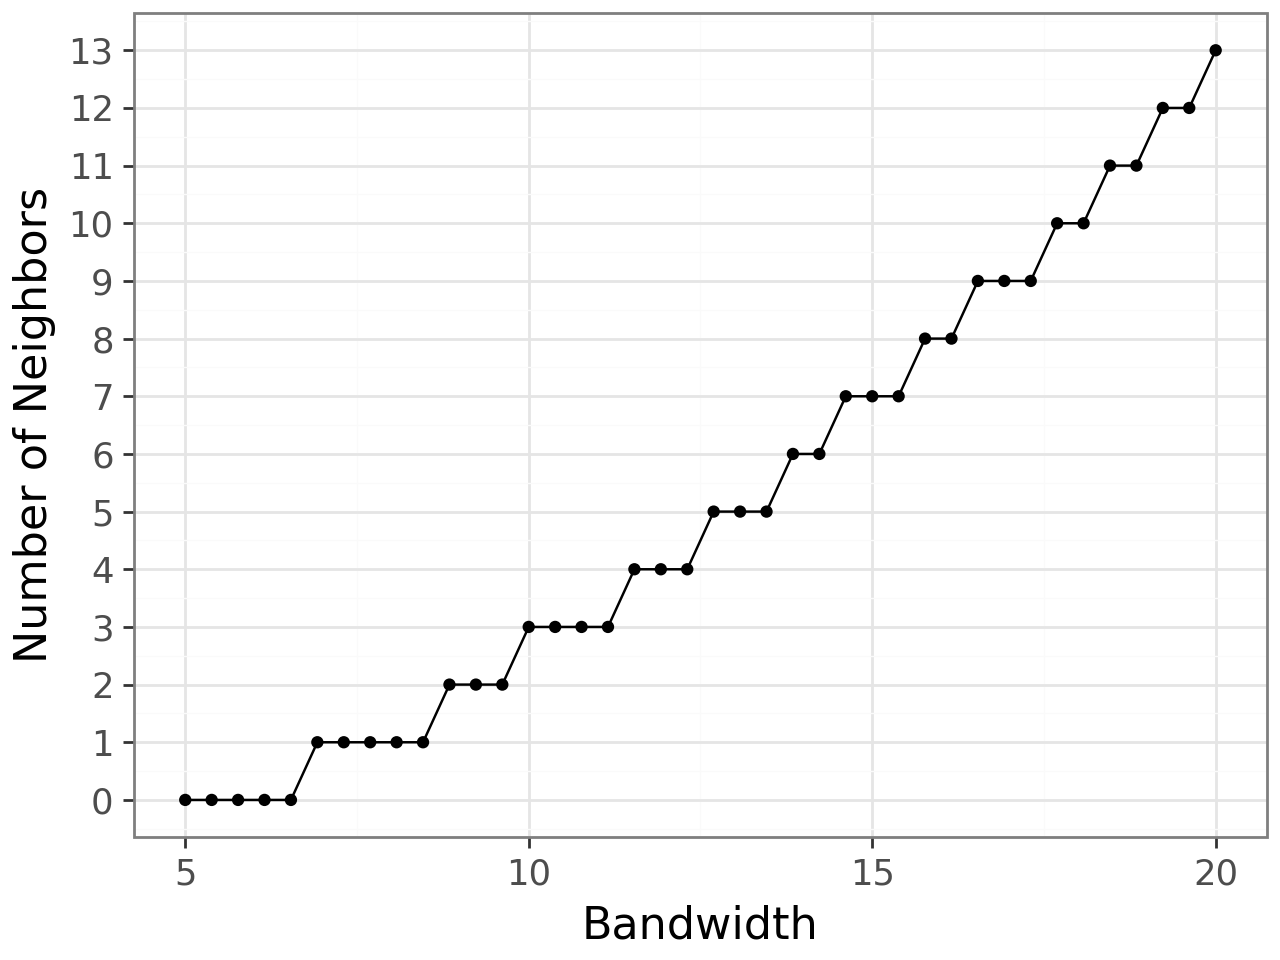

In [16]:
# around the sweet spot you explored
plot, df = li.ut.query_bandwidth(
    coordinates=adata.obsm["spatial"],
    start=5,         
    end=20,           
    interval_n=40    
)
plot + scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

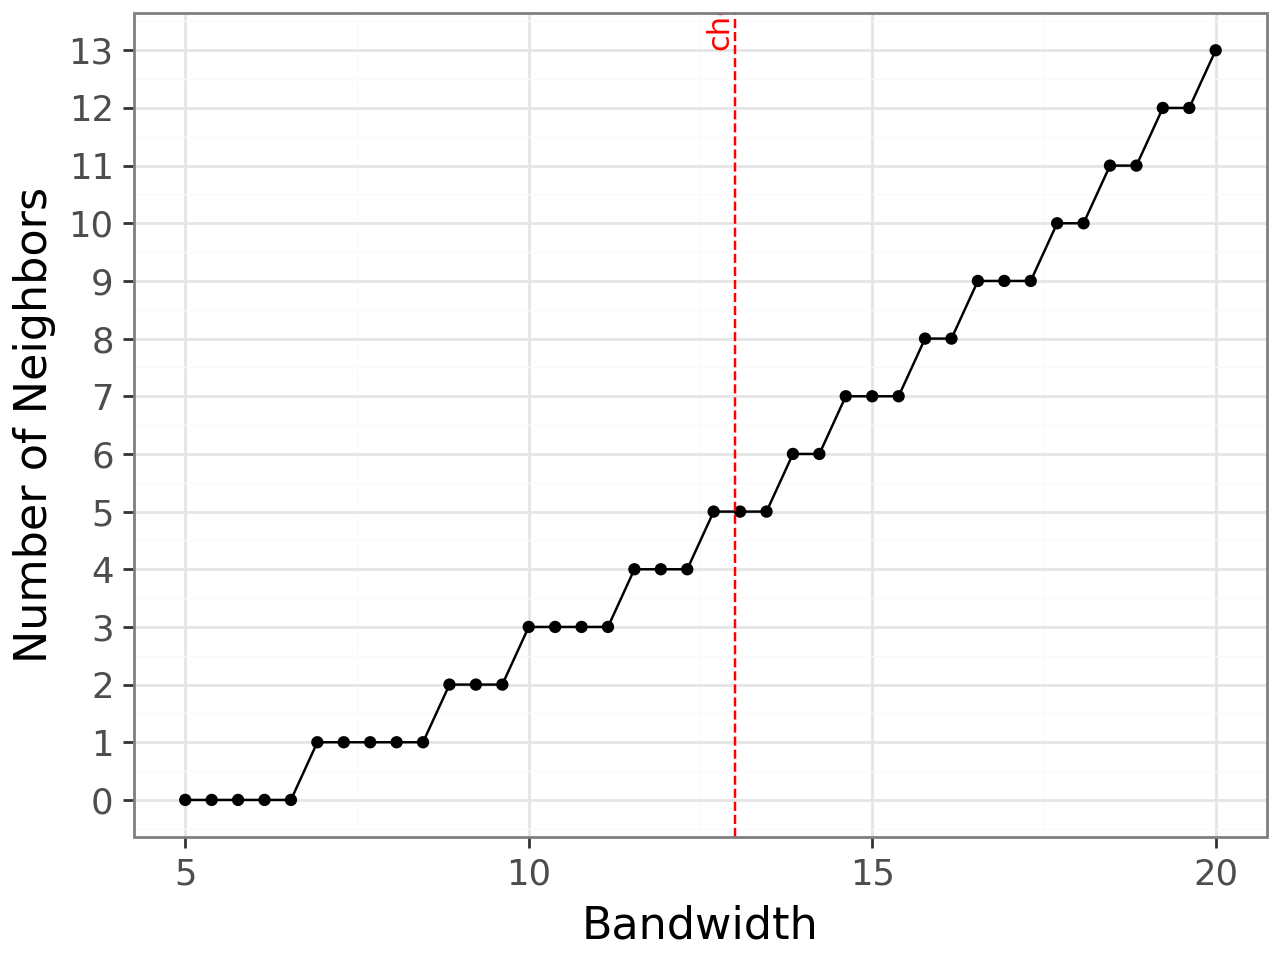

In [17]:
chosen = 13
plot + geom_vline(xintercept=chosen, linetype="dashed", color="red") + \
       annotate("text", x=chosen, y=df.neighbours.max(), 
                label=f"chosen={chosen}µm",
                angle=90, va="bottom", ha="right", color="red") + \
       scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

Run spatial neighbors and connectivity

In [37]:
li.ut.spatial_neighbors(adata=adata, bandwidth=13)

## Visualize proximity

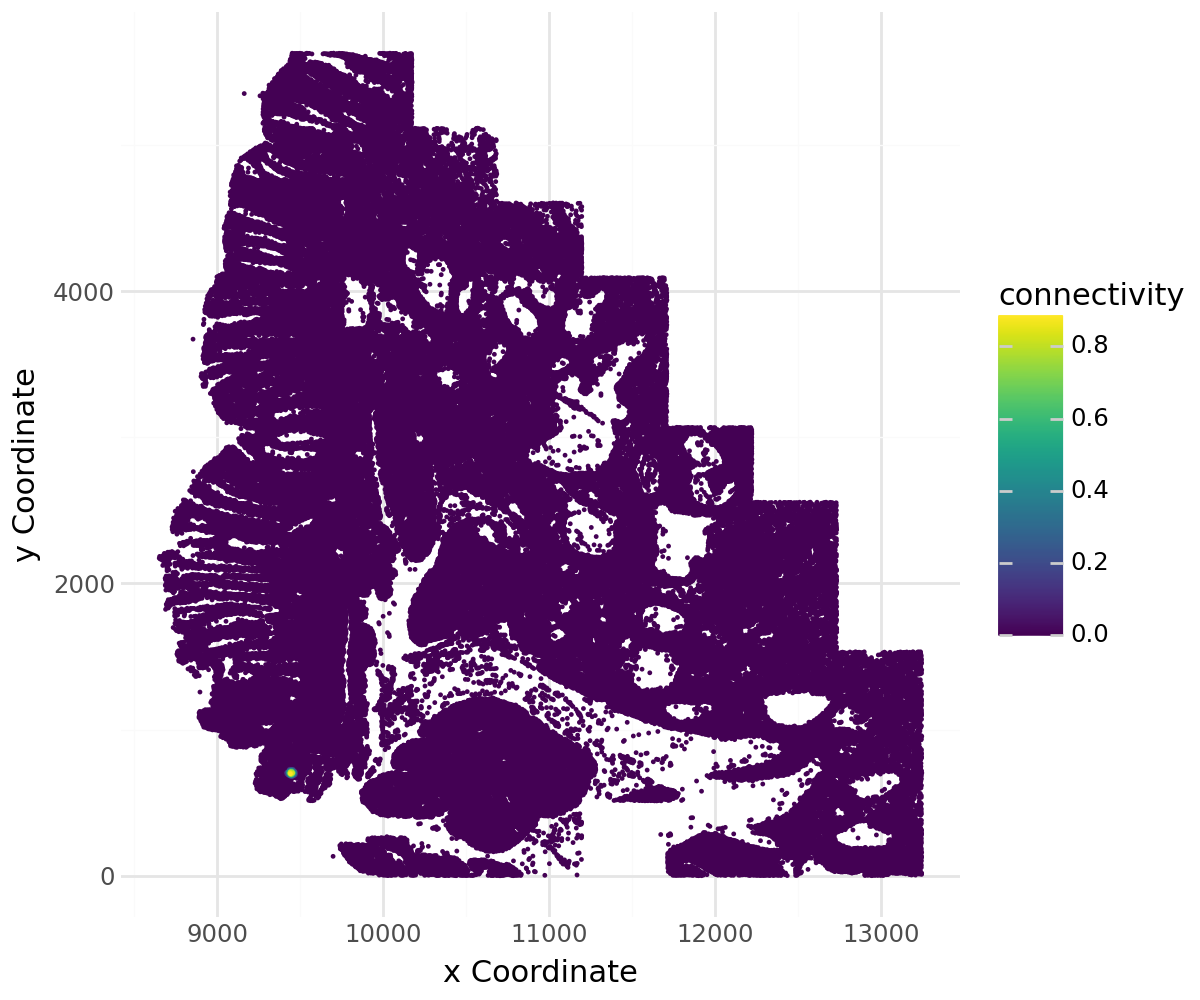

In [38]:
li.pl.connectivity(adata, idx=8000, size=0.001, figure_size=(6, 5))

In [27]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, 
                       show_progress_bar=True)

In [28]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
FABP1,0.512369,0.000000,9.860847e-07,0.000000
COL1A1,0.471486,0.000000,9.860847e-07,0.000000
S100A6,0.458592,0.000000,9.860847e-07,0.000000
S100A4,0.454387,0.000000,9.860847e-07,0.000000
KRT8,0.407383,0.000000,9.860847e-07,0.000000
...,...,...,...,...
CST11,-0.001433,0.075606,9.860847e-07,0.092379
FAM133A,-0.001457,0.072283,9.860847e-07,0.088714
NR1H4,-0.001485,0.068468,9.860847e-07,0.084646
LEPROT,-0.001634,0.050766,9.860847e-07,0.065253


## Check spatially variable genes (SVGs)

In [39]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

2322

![SVGs_options](../_static/SVGs_plot.png)

### Option1: filter by SVGs 

Filtering your adata by SVGs (Spatially Variable Genes) means selecting only those LR interactions where BOTH the ligand and the receptor genes show spatial variability.
<br>

Keep in mind that applying this filter may reduce the number of detected LR pairs, possibly excluding biologically meaningful interactions where only one partner is spatially variable.
<br>

In this tutorial, we will use this filter for faster calculations
</br>

In [40]:
adata = adata[:, svgs]

### Option2: filter by SVGs and their pair

This option filters out ligand–receptor (LR) pairs only when neither the ligand nor the receptor is spatially variable.

In [ ]:
#retrive LR database
lr = li.rs.select_resource()
ligand_set = set(lr['ligand']) #1027
receptor_set = set(lr['receptor']) #1052

In [ ]:
svgs_df = adata.uns['moranI'][(adata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (adata.uns['moranI']['I'] > 0.01)]

In [ ]:
sorted_filtered = svgs_df.reset_index().rename(columns={'index': 'gene'})

# Create lookup dictionary for faster access
moran_dict = dict(zip(sorted_filtered['gene'], sorted_filtered['I']))

# Map Moran's I values to ligand and receptor
lr['ligand_moran_I'] = lr['ligand'].map(moran_dict)
lr['receptor_moran_I'] = lr['receptor'].map(moran_dict)

In [ ]:
lr_filtered = lr[~(lr['ligand_moran_I'].isna() & lr['receptor_moran_I'].isna())]

In [ ]:
genes_to_keep = np.unique(
    lr_filtered['ligand'].unique().tolist() + 
    lr_filtered['receptor'].unique().tolist()
)

In [ ]:
adata_filtered = adata[:, adata.var_names.isin(genes_to_keep)].copy()

## Compute inflow score 

In [15]:
lrdata = li.mt.inflow(adata,  
                                  groupby='ist', # cell type columns
                                  resource_name='cellchatdb',
                                  use_raw=False)
                                  
lrdata.shape

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(129915, 784)

### Compute global score

In [23]:
li.mt.compute_global_score(lrdata, groupby='ist')

/g/stegle/aalsayah/repos/liana-py/liana/method/sc/_compute_global_score.py:89: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [24]:
lrdata.uns["global_score"].sort_values('lr_mean').tail()

,ligand,ligand_complex,receptor,receptor_complex,source,target,lr_mean
2765,MDK,MDK,NCL,NCL,epi4,epi4,0.219324
4416,COL1A1,COL1A1,SDC1,SDC1,fib2,fib2,0.229924
1384,MDK,MDK,NCL,NCL,epi2,epi2,0.236179
4356,COL1A1,COL1A1,CD44,CD44,fib2,fib2,0.255594
2935,COL1A1,COL1A1,SDC4,SDC4,fib2,epi4,0.287243


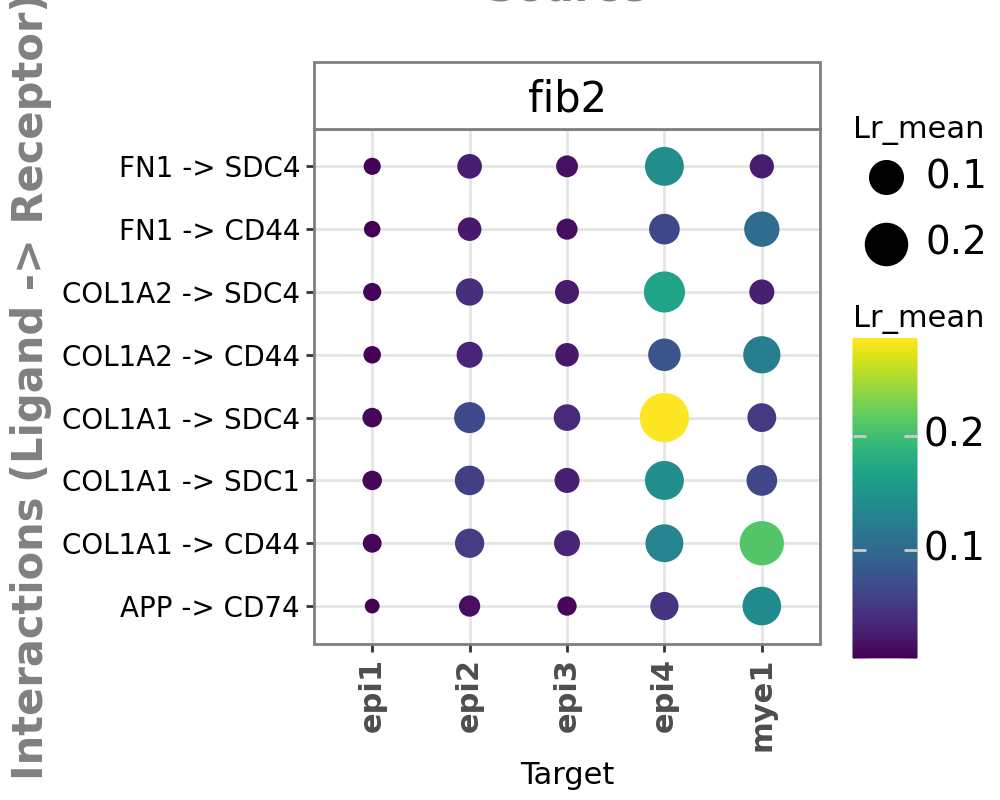

In [25]:
li.pl.dotplot(adata = lrdata, 
              colour='lr_mean',
              size = "lr_mean",
              source_labels=['fib2'],
              target_labels=['epi1', "epi4", "epi3", "epi2", "mye1"],
              filter_fun=lambda x: x['lr_mean'] > 0.1,
              figure_size=(5, 4),
              uns_key='global_score' 
             )

## Optional: filter data to keep only spatially variable LR interaction

In [16]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [17]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]

In [18]:
len(svis)

690

In [19]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
fib2^CEACAM1^CEACAM5,0.217356,0.0,1.608876e-07,0.0
mye2^CEACAM1^CEACAM5,0.226716,0.0,1.608876e-07,0.0
mye1^CEACAM1^CEACAM5,0.241905,0.0,1.608876e-07,0.0
epi3^MDK^NCL,0.261539,0.0,1.608876e-07,0.0
epi4^MDK^NCL,0.326481,0.0,1.608876e-07,0.0
epi2^MDK^NCL,0.340160,0.0,1.608876e-07,0.0
epi3^CEACAM1^CEACAM5,0.376875,0.0,1.608876e-07,0.0
epi1^CEACAM1^CEACAM5,0.382330,0.0,1.608876e-07,0.0
epi2^CEACAM1^CEACAM5,0.392461,0.0,1.608876e-07,0.0
epi4^CEACAM1^CEACAM5,0.464224,0.0,1.608876e-07,0.0


## Plot layout of chosen interactions

In [20]:
adata.layers['transformed'] = li.utils.zi_minmax(adata.X, cutoff=0.01)

/tmp/ipykernel_2743272/3987365680.py:1: ImplicitModificationWarning: Setting element `.layers['transformed']` of view, initializing view as actual.


/tmp/ipykernel_2743272/892736459.py:19: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:21: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:25: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:27: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:29: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


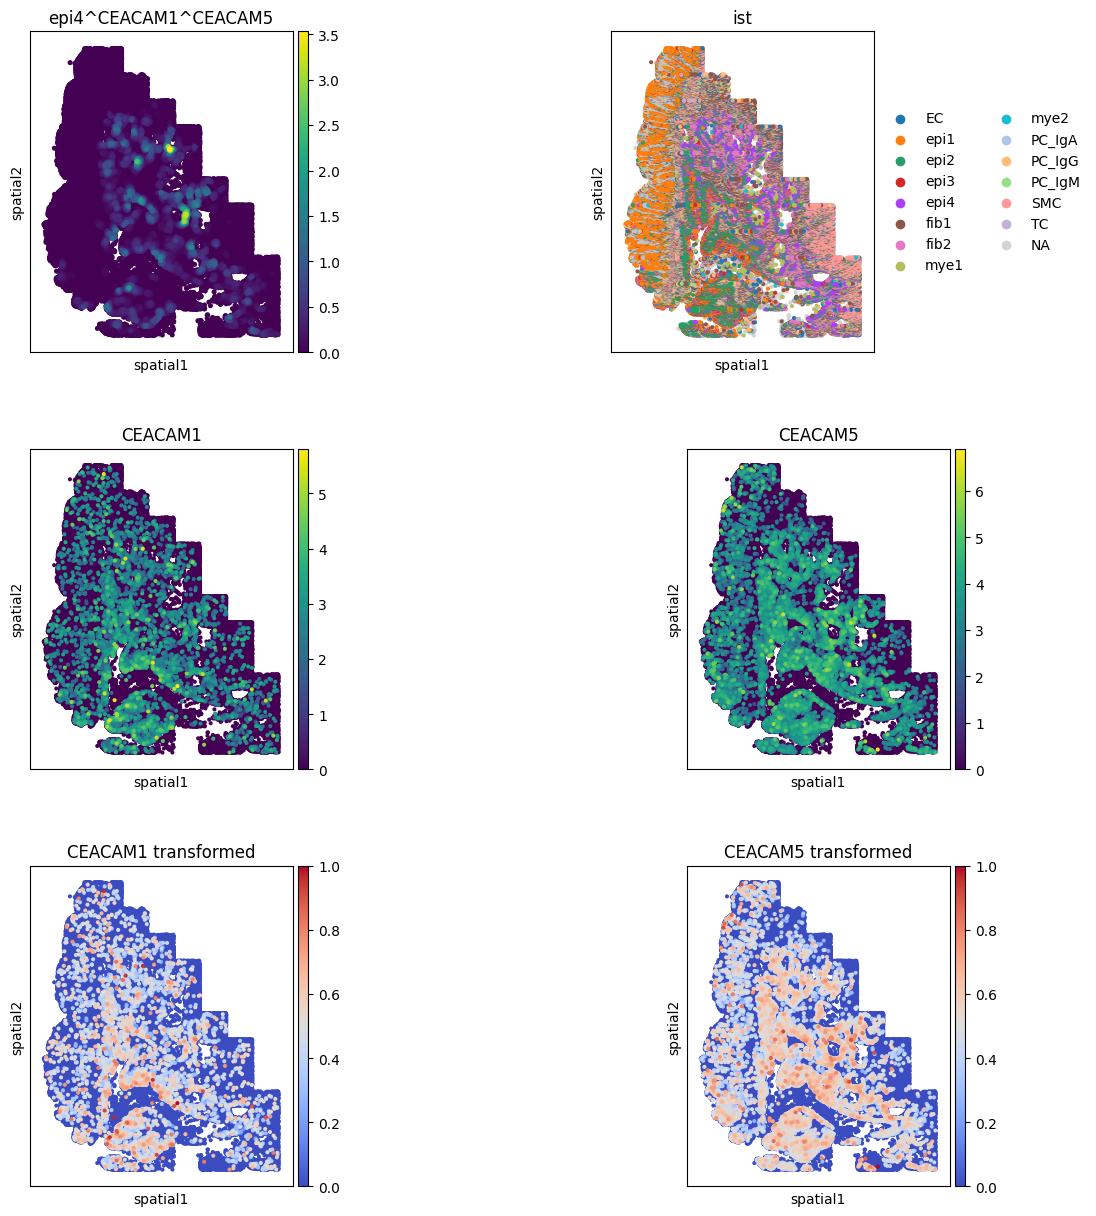

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

# Define your keys
key = 'epi4^CEACAM1^CEACAM5' 
xy_sep = '^'
groupby = 'ist'
keys = key.split(xy_sep)

if len(keys) < 2:
    raise ValueError("The 'key' variable should contain at least two elements separated by '&'.")

ligand = keys[1]
receptor = keys[2]

adata.obs['receptor'] = (adata[:, receptor].X > 0).toarray().flatten()

sc.pl.spatial(lrdata, color=[key], spot_size=100, ax=axes[0],show=False)
axes[0].set_title(f"{key}")
sc.pl.spatial(adata, color=[groupby], spot_size=80, ax=axes[1],show=False)
axes[1].set_title(f"{groupby}")
sc.pl.spatial(adata, color=[ligand], spot_size=80, ax=axes[2], show=False)
axes[2].set_title(f"{ligand}")
sc.pl.spatial(adata, color=[receptor], spot_size=80, ax=axes[3], show=False)
axes[3].set_title(f"{receptor}")
sc.pl.spatial(adata, color=[ligand], spot_size=80, ax=axes[4], show=False, layer='transformed', cmap='coolwarm')
axes[4].set_title(f"{ligand} transformed")
sc.pl.spatial(adata, color=[receptor], spot_size=80, ax=axes[5], show=False, layer='transformed', cmap='coolwarm')
axes[5].set_title(f"{receptor} transformed")
plt.show()